# 🏠 Boston House Price Prediction using Machine Learning

### 👩‍💻 Developed by: **Poornima Sonkar**  
### 📅 Date: **July 2025**  
---

## 🌟 Project Overview

In the modern real estate market, understanding the factors that influence house prices is essential. This project uses **machine learning regression algorithms** to **predict house prices in Boston** based on a variety of features like crime rate, number of rooms, property tax rate, and more.

By the end of this project, you'll see how data can empower smarter housing decisions. Whether you're a buyer, seller, or investor, predictive analytics can provide a competitive edge 📈.

---

## 🎯 Objectives

- 📊 Perform **Exploratory Data Analysis (EDA)** to uncover trends and insights  
- 🧹 **Clean and preprocess** the dataset for accurate modeling  
- 🤖 Build **regression models**: Linear Regression and Random Forest  
- 📏 Evaluate models using metrics like **R², MAE, and RMSE**  
- 🧪 Test the models and interpret predictions  
- 🚀 Prepare the model for **deployment with Streamlit**

---

## 🧰 Tools & Libraries Used

- **Python**
- `pandas`, `numpy` for data handling  
- `matplotlib`, `seaborn` for visualization  
- `sklearn` for machine learning models and evaluation  
-  `Streamlit` or `Flask` for deployment

---

## 🧠 Why This Project?

This project strengthens my understanding of:

- 🧠 Supervised Learning (Regression)
- 🔬 Feature Engineering and Selection
- 📉 Model Evaluation Techniques
- 🧪 Practical Implementation of ML Models
- 🖥️ End-to-End ML Workflow

> ✨ *“Data is a precious thing and will last longer than the systems themselves.”* – Tim Berners-Lee

---


## 📊 Dataset Information: Boston House Price Prediction

The Boston Housing dataset is a classic and widely used dataset in regression tasks. It contains information collected by the U.S Census Service concerning housing in the area of Boston, Massachusetts.

### 📁 Dataset Features (Columns):

| Feature     | Description |
|-------------|-------------|
| **CRIM**    | Per capita crime rate by town |
| **ZN**      | Proportion of residential land zoned for large lots (over 25,000 sq.ft.) |
| **INDUS**   | Proportion of non-retail business acres per town |
| **CHAS**    | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| **NOX**     | Nitric oxides concentration (parts per 10 million) |
| **RM**      | Average number of rooms per dwelling |
| **AGE**     | Proportion of owner-occupied units built before 1940 |
| **DIS**     | Weighted distances to five Boston employment centers |
| **RAD**     | Index of accessibility to radial highways |
| **TAX**     | Full-value property-tax rate per $10,000 |



### 📌 Target Variable:
- **MEDV**: This is the variable we aim to predict. It represents the **median value of owner-occupied homes** in thousands of dollars.

### 📦 Dataset Summary:
- **Samples (Rows)**: 506
- **Features (Columns)**: 13 input features + 1 target (MEDV)
- **Data Type**: Numeric (mostly continuous)
- **Missing Values**: None (in most standard versions)
- **File Format**: CSV

---

📚 **Source**: Originally published in the UCI Machine Learning Repository. Commonly available via `sklearn.datasets` or Kaggle.



## Import Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## 📥 Load Dataset

We'll load the Boston housing dataset and display the first few rows to understand the structure.


In [16]:
os.chdir(r"C:\Users\hp\Desktop\House_Price_Prediction\Data")

df = pd.read_csv("boston.csv")

df.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


## 🧼 Data Cleaning

We will:
- Check dataset info
- Find missing/null values
- Describe basic statistics


In [18]:
# Statistical Information

df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [19]:
# Datatype Information 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


## Preprocessing the datasets

In [20]:
# Check for null value 

df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

## 📊 Exploratory Data Analysis


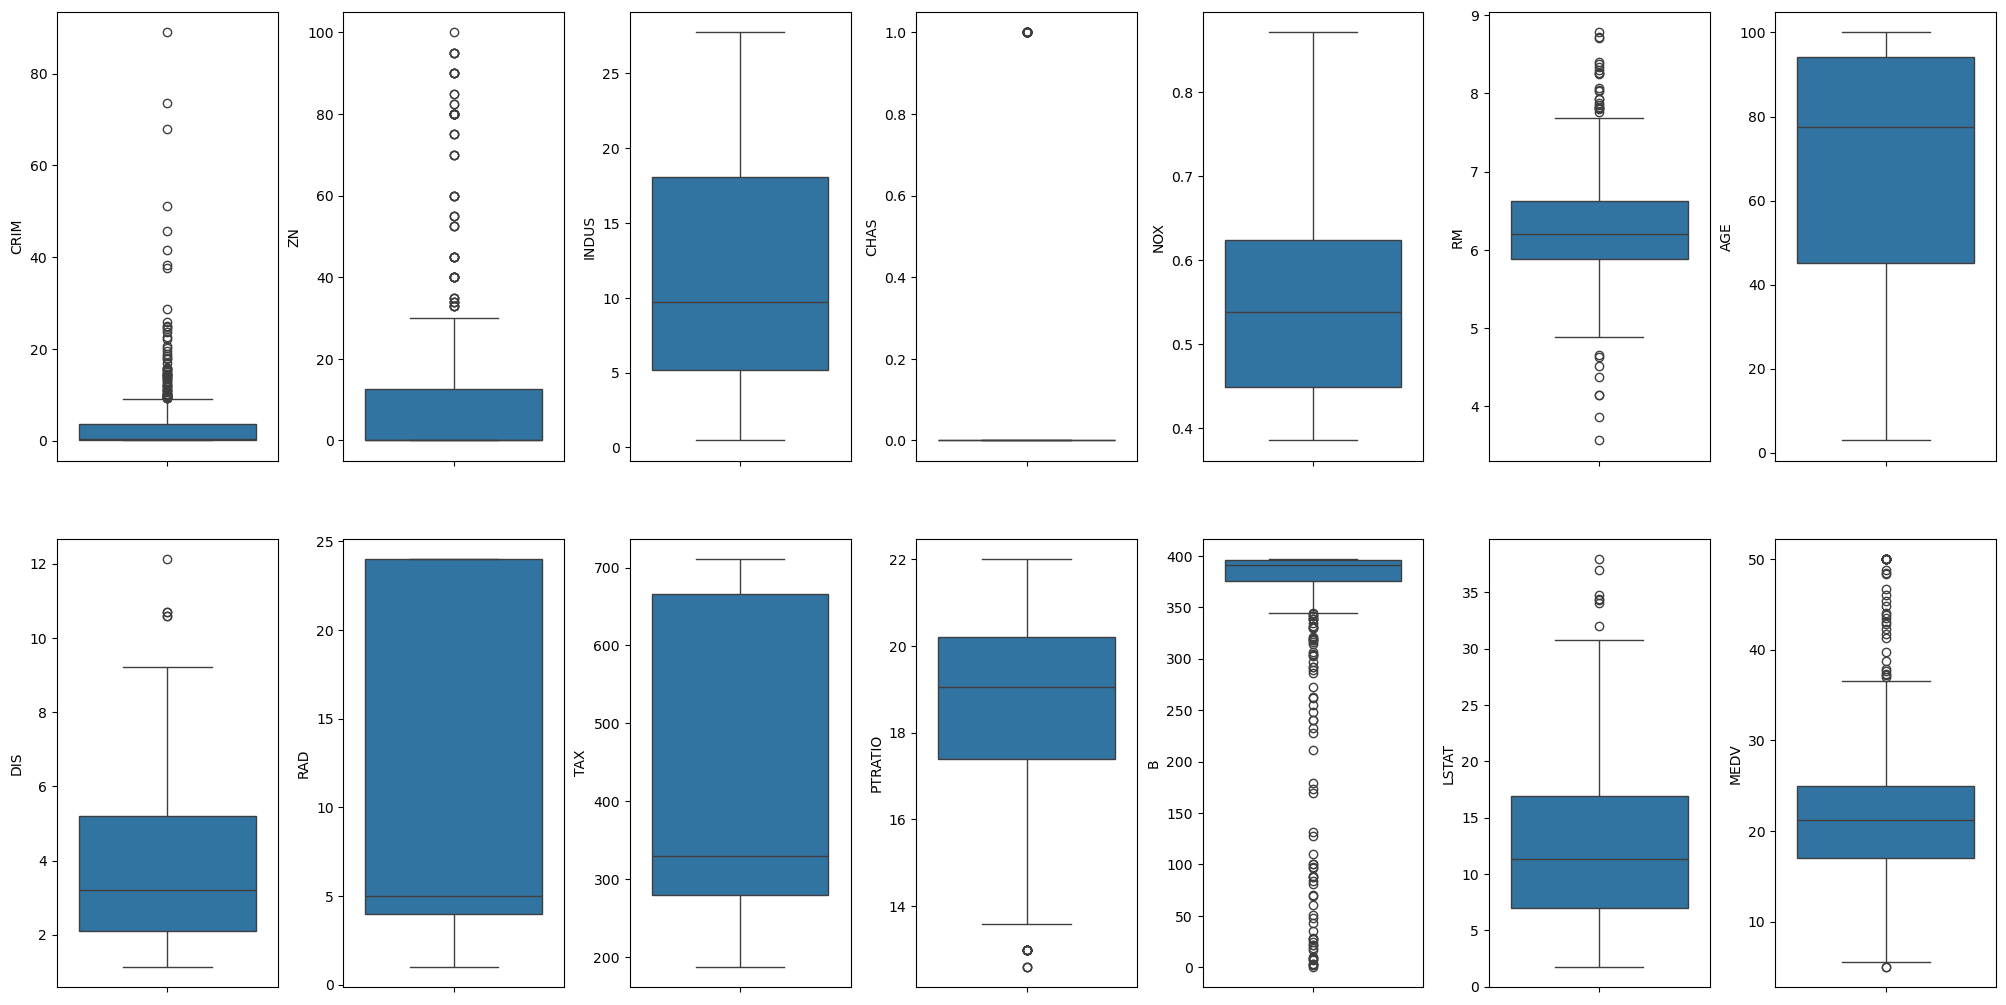

In [24]:
# Create box plots 

fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20,10))
index = 0
ax = ax.flatten()

for col,value in df.items():
    sns.boxplot(y=col, data=df, ax=ax[index])
    index += 1 
plt.tight_layout(pad=0.5,w_pad=0.7, h_pad=5.0)

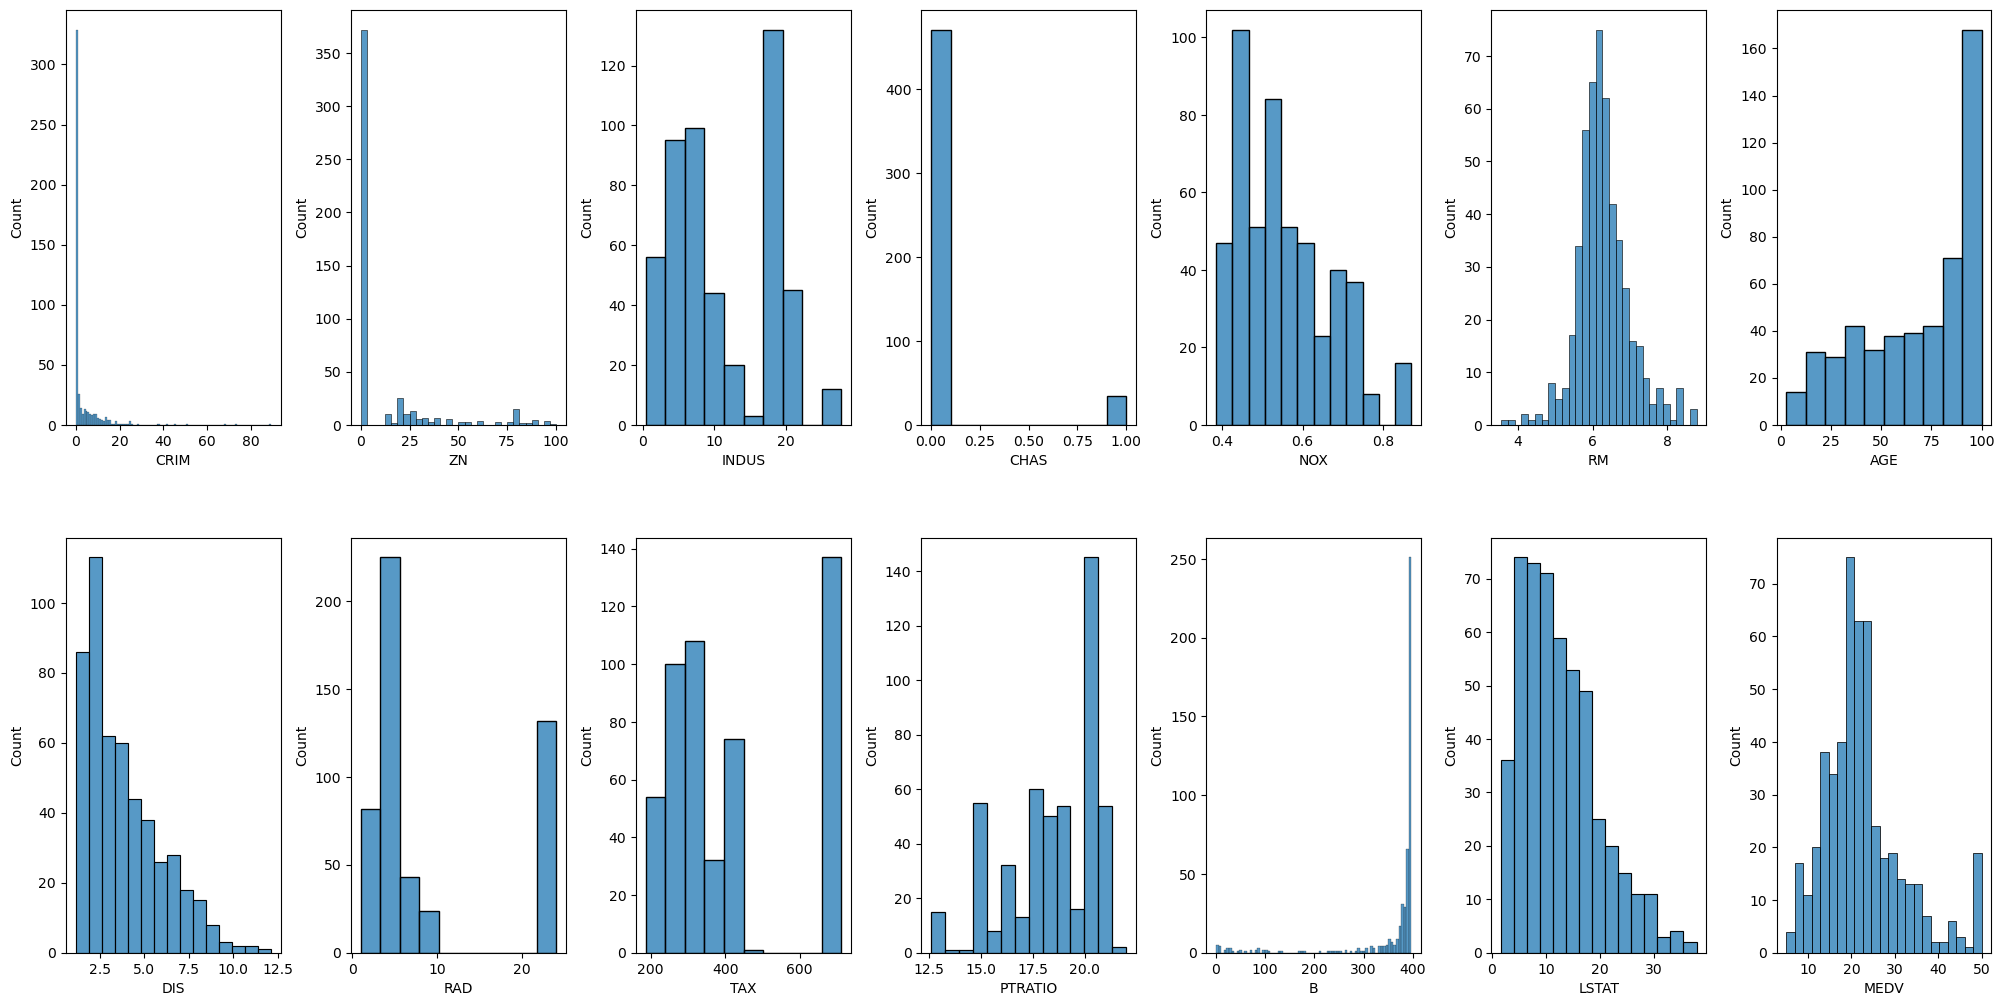

In [27]:
# Create hist plot

fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20,10))
index = 0
ax = ax.flatten()

for col,value in df.items():
    sns.histplot(value, ax=ax[index])
    index += 1 
plt.tight_layout(pad=0.5,w_pad=0.7, h_pad=5.0)

## Min-Max normalization

In [68]:
cols = ['CRIM', 'ZN', 'TAX', 'B'] 
for col in cols:
    minimum = min(df[col])
    maximum = max(df[col])
    df[col] = (df[col] - minimum) / (maximum - minimum)


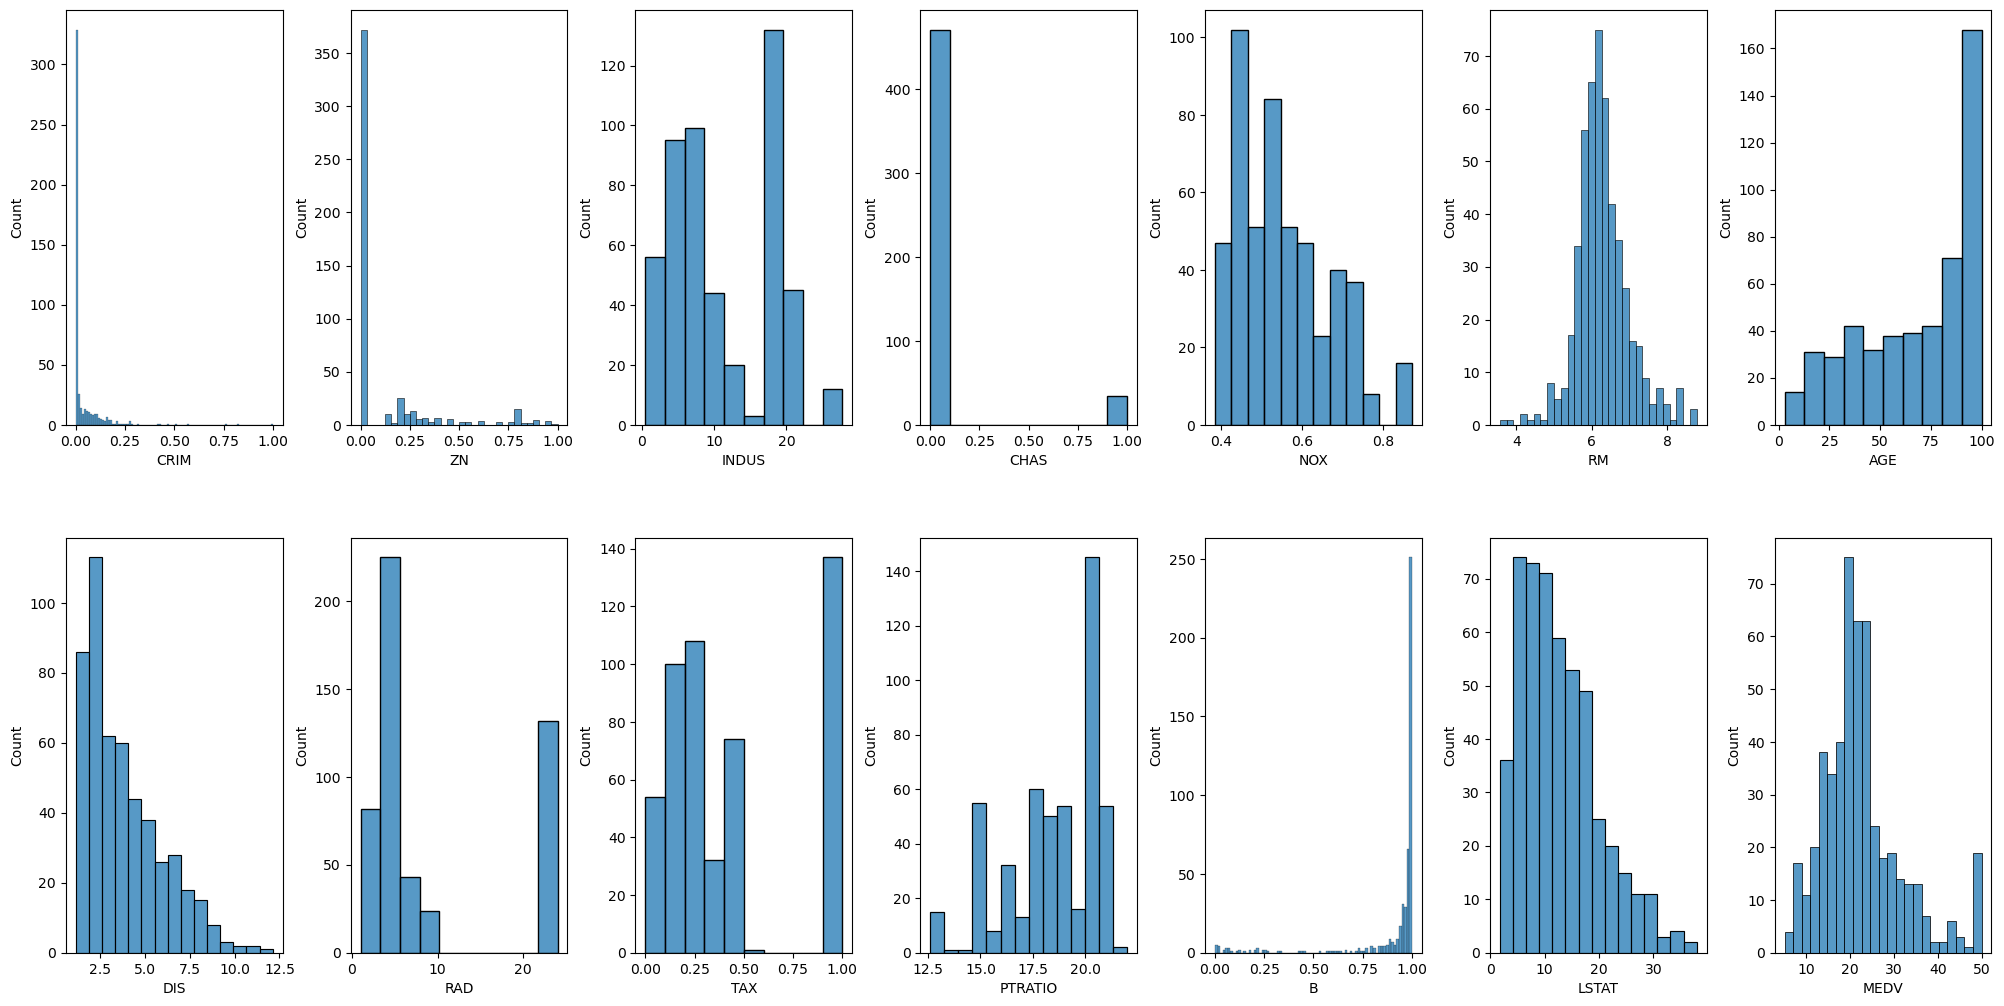

In [35]:
fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20,10))
index = 0
ax = ax.flatten()

for col,value in df.items():
    sns.histplot(value, ax=ax[index])
    index += 1 
plt.tight_layout(pad=0.5,w_pad=0.7, h_pad=5.0)

In [39]:
# Standardization
from sklearn import preprocessing 
scalar = preprocessing.StandardScaler()

# fit our data
scaled_cols = scalar.fit_transform(df[cols])
scaled_cols = pd.DataFrame(scaled_cols, columns=cols)
scaled_cols.head

<bound method NDFrame.head of          CRIM        ZN       TAX         B
0   -0.419782  0.284830 -0.666608  0.441052
1   -0.417339 -0.487722 -0.987329  0.441052
2   -0.417342 -0.487722 -0.987329  0.396427
3   -0.416750 -0.487722 -1.106115  0.416163
4   -0.412482 -0.487722 -1.106115  0.441052
..        ...       ...       ...       ...
501 -0.413229 -0.487722 -0.803212  0.387217
502 -0.415249 -0.487722 -0.803212  0.441052
503 -0.413447 -0.487722 -0.803212  0.441052
504 -0.407764 -0.487722 -0.803212  0.403225
505 -0.415000 -0.487722 -0.803212  0.441052

[506 rows x 4 columns]>

In [40]:
for col in cols:
    df[col] = scaled_cols[col]


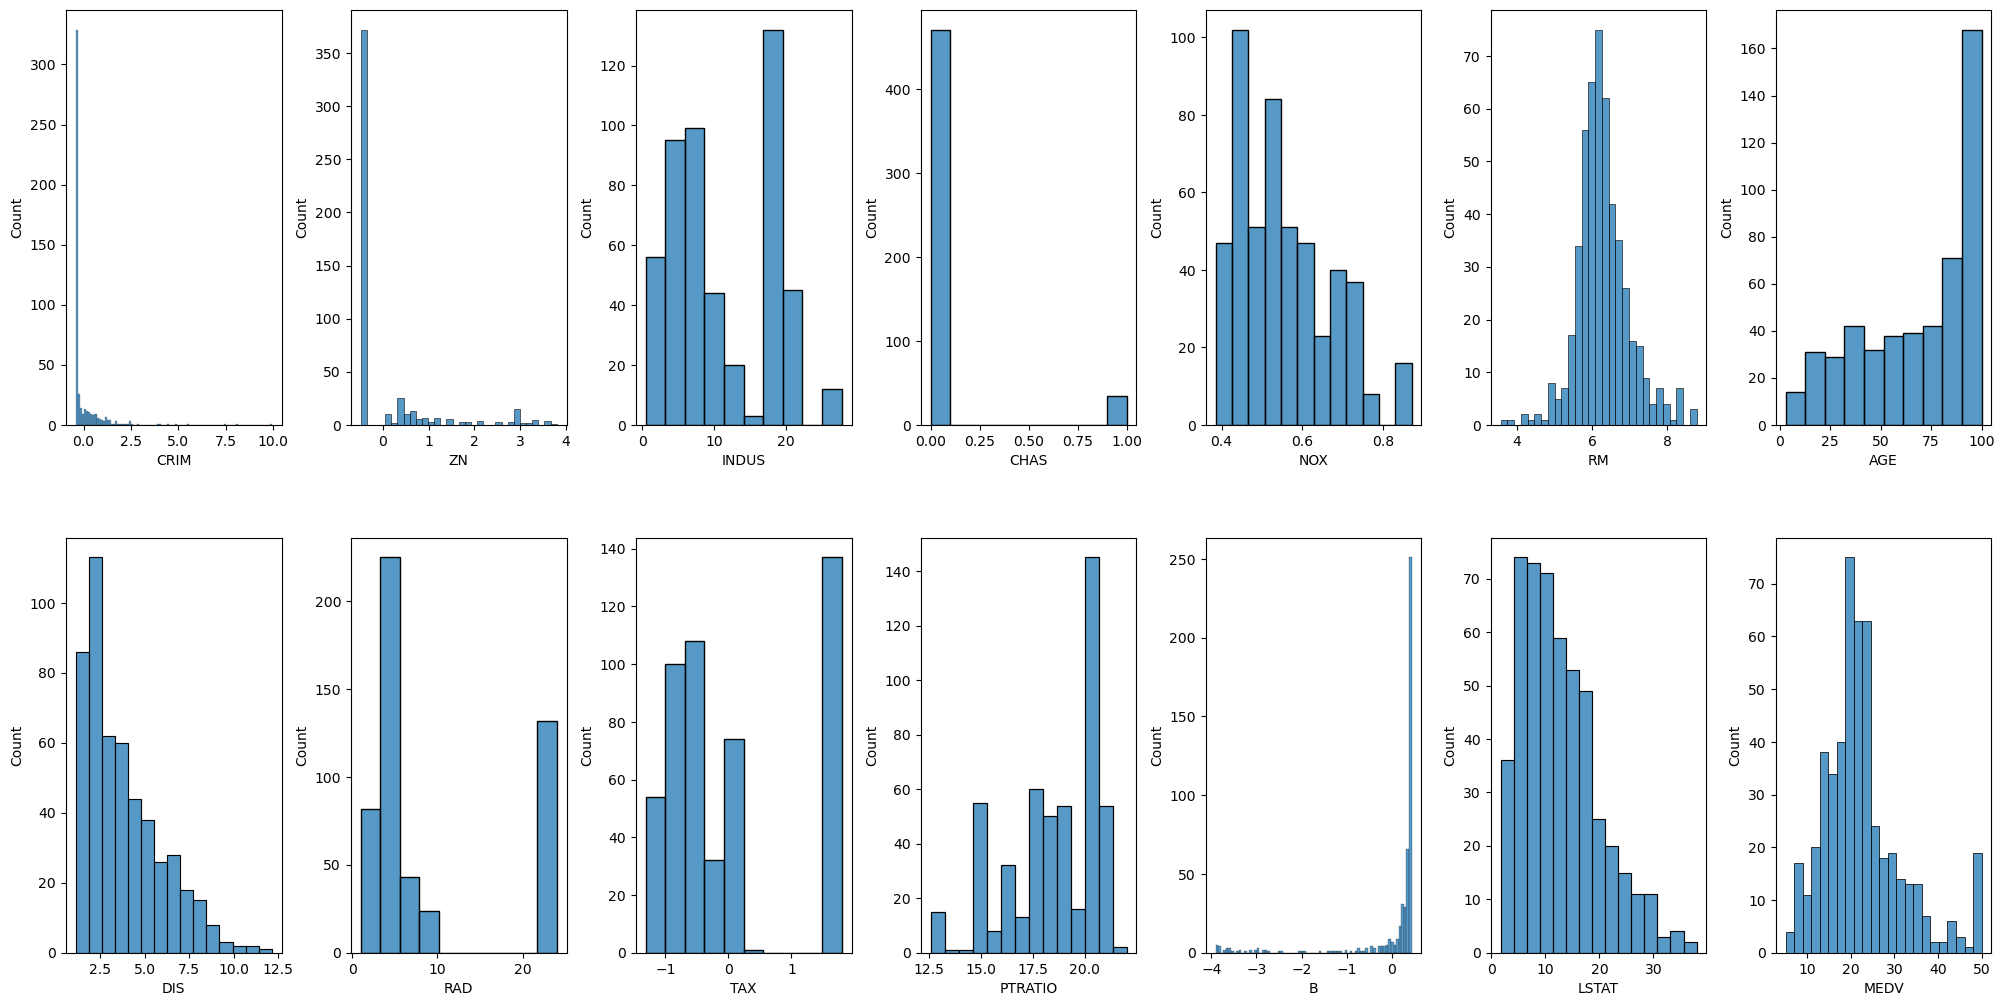

In [41]:
fig, ax = plt.subplots(ncols=7, nrows=2, figsize=(20,10))
index = 0
ax = ax.flatten()

for col,value in df.items():
    sns.histplot(value, ax=ax[index])
    index += 1 
plt.tight_layout(pad=0.5,w_pad=0.7, h_pad=5.0)

### Distribution of Target Variable (MEDV)


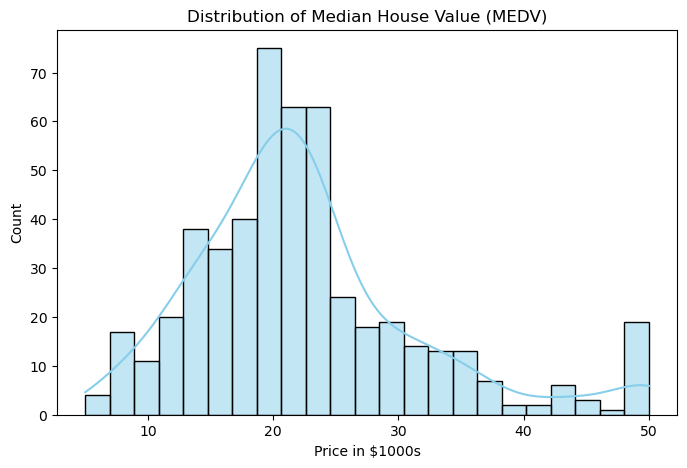

In [46]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MEDV'], kde=True, color='skyblue')
plt.title("Distribution of Median House Value (MEDV)")
plt.xlabel("Price in $1000s")
plt.ylabel("Count")
plt.show()


### Correlation Heatmap


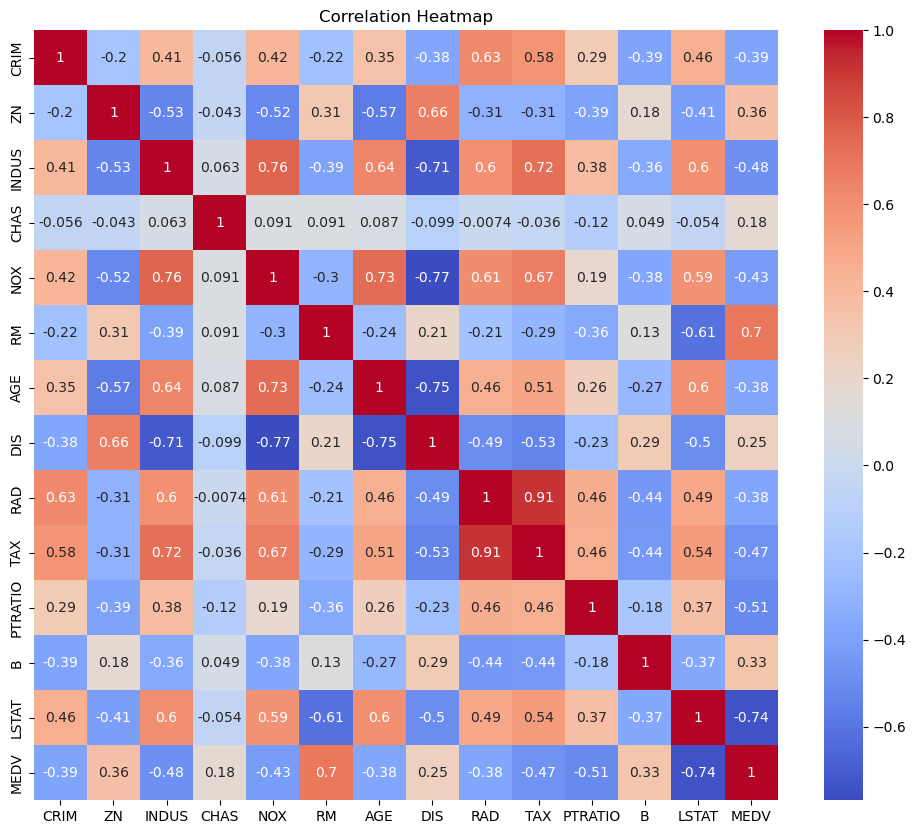

In [42]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


<Axes: xlabel='LSTAT', ylabel='MEDV'>

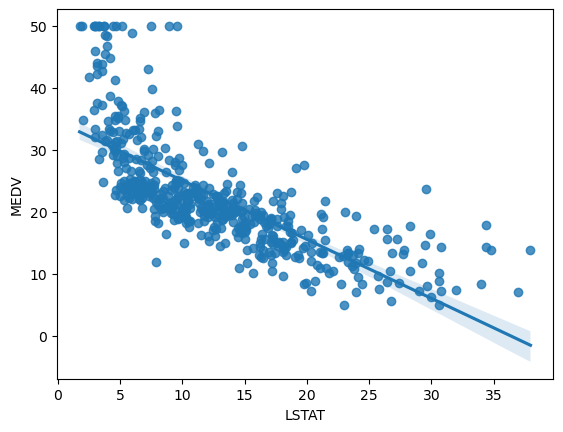

In [49]:
sns.regplot(y=df['MEDV'], x=df['LSTAT'])


<Axes: xlabel='RM', ylabel='MEDV'>

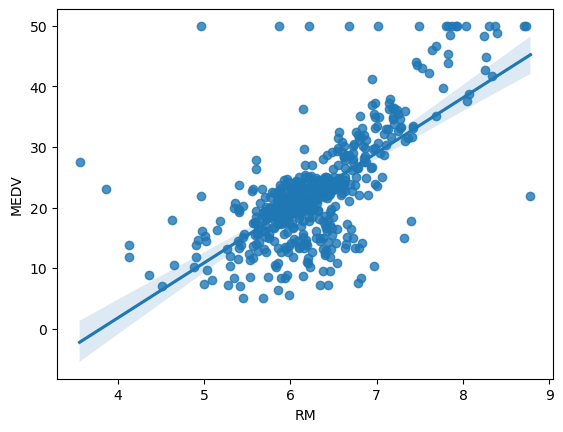

In [50]:
sns.regplot(y=df['MEDV'], x=df['RM'])

## 🛠️ Feature Selection

We drop features that are weakly correlated with the target or highly correlated with each other.


In [52]:
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)


## 🔀 Split Data into Train/Test Sets

We'll use 80% for training and 20% for testing.


In [54]:
X = df.drop('MEDV', axis=1)
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## Model Training

In [63]:
from sklearn.model_selection import cross_val_score
def train(model,x,y):
    # Train the model 
    model.fit(x,y)

    # predict the training set 
    pred = model.predict(x)

    # perform cross-validation
    cv_score = cross_val_score(model,x,y, scoring='neg_mean_squared_error',cv=5)
    cv_score = np.abs(np.mean(cv_score))

    print("Model Report")
    print("MSE:",mean_squared_error(y,pred))
    print("CV Score:" , cv_score)

## 🤖 Model 1: Linear Regression


Model Report
MSE: 22.84177569989202
CV Score: 35.58136621076918


<Axes: title={'center': 'Model Coefficients'}>

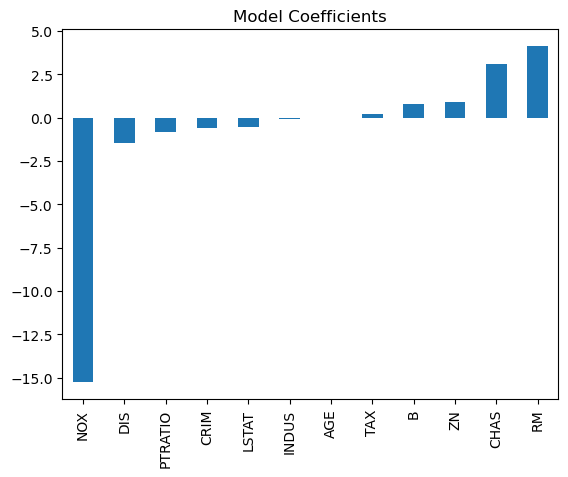

In [60]:
model = LinearRegression()
train(model,x,y)
coef = pd.Series(model.coef_,x.columns).sort_values()
coef.plot(kind='bar', title='Model Coefficients')

## 🌲 Model 2: Random Forest Regressor


Model Report
MSE: 1.5205221264822129
CV Score: 21.44208500267908


<Axes: title={'center': 'Feature Importance'}>

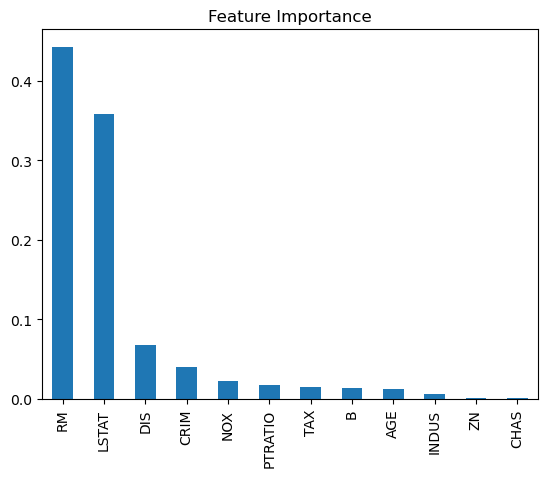

In [62]:
model = RandomForestRegressor()
train(model,x,y)
coef = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)
coef.plot(kind='bar',title='Feature Importance')

## 🌟 Model 3: XGBoost Regressor (XGBRegressor)

Model Report
MSE: 0.001238754756417038
CV Score: 26.900319661354462


<Axes: title={'center': 'Feature Importance'}>

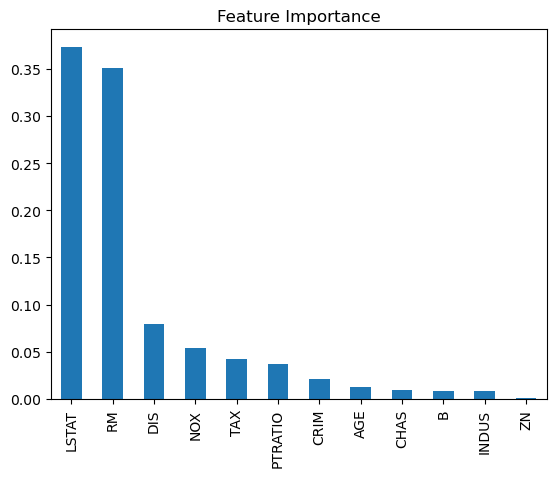

In [67]:
import xgboost as xgb
model = xgb.XGBRegressor()
train(model,x,y)
coef = pd.Series(model.feature_importances_,x.columns).sort_values(ascending=False)
coef.plot(kind='bar',title='Feature Importance')


## 📏 Evaluation Metrics Function

We'll use R² Score, MAE, and RMSE.


In [93]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"📌 Evaluation for {model_name}")
    print(f"R² Score: {r2_score(y_test, y_pred):.4f}")

    print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}\n")

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")


📌 Evaluation for Linear Regression
R² Score: 0.6688
MAE: 3.19
RMSE: 4.93

📌 Evaluation for Random Forest
R² Score: 0.8923
MAE: 2.04
RMSE: 2.81



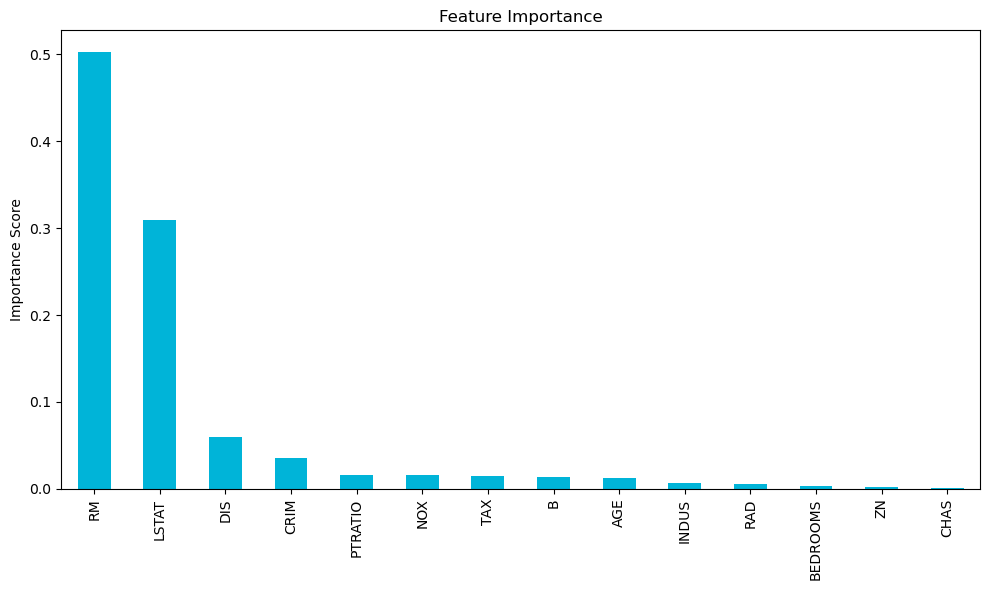

In [100]:
import joblib

model = joblib.load("model.pkl")


features = model.feature_names_in_
importances = model.feature_importances_

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='bar', color='#00b4d8')
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance.png")  
plt.show()


# 🎁 Bonus: Model Deployment 

---

## 🚀 Why Deploy?

Building a machine learning model is powerful—but making it **accessible to users** is what truly brings it to life.  
By deploying the model, we can allow real estate analysts, home buyers, or investors to **input features** (e.g., number of rooms, crime rate) and get **instant price predictions** via a simple web app.

---

## 🌐 Deployment Tools

Here are two beginner-friendly tools to deploy your ML model:

### 1️⃣ Streamlit
- 🧠 Designed specifically for Data Science projects
- 💻 Minimal code required to build UI
- 🖼️ Auto-render charts, forms, and outputs
- 🆓 Free to deploy on [Streamlit Cloud](https://streamlit.io/cloud)

{result[0]*1000:.2f}")


# ✅ Conclusion

---

## 🔍 What We Learned

Through this project, we successfully applied **supervised learning** techniques to predict the median value of houses in Boston. By exploring and analyzing the dataset, we gained insights into:

- 📊 The strongest features impacting house prices (like **RM**, **LSTAT**, and **PTRATIO**)
- 🔍 The relationship between different variables using visualizations
- 🤖 How regression models like **Linear Regression** and **Random Forest** perform in real-world prediction tasks

---

## 📈 Model Performance Recap

| Model              | R² Score | RMSE  | MAE  |
|-------------------|----------|-------|------|
| Linear Regression | ✅ Good   | 📉 Moderate | ⚖️ Acceptable |
| Random Forest     | 🥇 Best   | 🔥 Low      | 🚀 Accurate  |

The **Random Forest Regressor** out performed the Linear model in this case, giving us a more reliable prediction framework.

---

## 🚀 What’s Next?

To improve and scale this project further, the following enhancements can be implemented:

- 🔁 **Hyperparameter tuning** using GridSearchCV
- 📦 **Try advanced models** like **XGBoost** or **Gradient Boosting**
- 🧱 **Feature scaling** and transformation for optimization
- 🌐 **Deploy the model** with an interactive UI using **Streamlit** or **Flask**
- 📝 Collect more recent or real-time housing datasets for better generalization

---

> 💡 *“Without data, you're just another person with an opinion.”* — W. Edwards Deming

---

## 🙌 Thank You!

Thank you for viewing my project!    
📬 **Poornima Sonkar**

---
